## Dataset explanation

Size: 10 rows and 8 columns, so it is tiny and only good for practice.
Columns: id, first_name, last_name, email, age, city, salary, joined
Types: id and age are integers, salary is a decimal, and the rest are text. joined is text and should be converted to a date.

Data quality
Check	Result
Missing values	0 in every column
Duplicate rows	0
Unique emails	10 of 10

The data needs no cleaning, apart from converting joined to a date.

Summary statistics
	Age	Salary
Mean	46.9	103,713.77
Median	46	117,451.86
Std dev	18.76	65,217.19
Min	21	22,669.84
Max	76	189,641.05
Findings
Highest salary: Benjamin Rodriguez at 189,641.05. Lowest: Amelia Johnson at 22,669.84.
Salary by city: Greenville has the highest average (161,424) and Madison the lowest (22,670). With only 1–2 people per city, this is not a reliable pattern.
Cities: Fairview, Manchester and Greenville have 2 people each, and the other four cities have 1 each.
Age and salary: the correlation is 0.10, which is almost none. Age does not predict salary in this data.
Joining years: 2015, 2016 and 2020 have 2 joiners each, and 2021–2024 have 1 each.
Names: Emma appears 3 times and Amelia 2 times.
Features and target

For a practice regression task, use salary as the target and age, city and the joining year as features. Leave out id, first_name, last_name and email, because they are identifiers and carry no useful signal. City would also need encoding, since it is text.

With only 10 rows and a 0.10 correlation, a model would not predict salary well. Treat this as a workflow exercise, not a real prediction task.

Train/test split (80/20, random_state=42)

This gives 8 training rows and 2 test rows. The test rows are ids 9 and 2.

Cell 1: Load

In [1]:
import pandas as pd
df = pd.read_csv("sample-simple.csv", parse_dates=["joined"])
df

,id,first_name,last_name,email,age,city,salary,joined
0,1,Liam,Williams,liam.williams1@sample.net,49,Riverside,156973.24,2020-04-18
1,2,Jane,Williams,jane.williams2@example.com,71,Fairview,50435.05,2024-01-27
2,3,Emma,Moore,emma.moore3@test.org,76,Fairview,128705.61,2022-01-06
3,4,Emma,Martinez,emma.martinez4@example.com,43,Burlington,106198.11,2016-01-05
4,5,Benjamin,Rodriguez,benjamin.rodriguez5@sample.net,62,Manchester,189641.05,2023-04-19
5,6,Amelia,Williams,amelia.williams6@demo.io,34,Manchester,26628.09,2016-08-19
6,7,Mia,Jones,mia.jones7@demo.io,21,Ashland,33038.53,2021-01-03
7,8,Emma,Lopez,emma.lopez8@demo.io,30,Greenville,146867.05,2015-12-15
8,9,Isabella,Lopez,isabella.lopez9@sample.net,29,Greenville,175981.13,2015-01-27
9,10,Amelia,Johnson,amelia.johnson10@demo.io,54,Madison,22669.84,2020-03-09


Cell 2: Explore

In [2]:
print(df.shape)
df.info()
print(df.isnull().sum())
print("Duplicates:", df.duplicated().sum())

(10, 8)
<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   id          10 non-null     int64         
 1   first_name  10 non-null     str           
 2   last_name   10 non-null     str           
 3   email       10 non-null     str           
 4   age         10 non-null     int64         
 5   city        10 non-null     str           
 6   salary      10 non-null     float64       
 7   joined      10 non-null     datetime64[us]
dtypes: datetime64[us](1), float64(1), int64(2), str(4)
memory usage: 772.0 bytes
id            0
first_name    0
last_name     0
email         0
age           0
city          0
salary        0
joined        0
dtype: int64
Duplicates: 0


Cell 3: Statistics

In [3]:
df[["age", "salary"]].describe().round(2)

,age,salary
count,10.00,10.00
mean,46.90,103713.77
std,18.76,65217.19
min,21.00,22669.84
25%,31.00,37387.66
50%,46.00,117451.86
75%,60.00,154446.69
max,76.00,189641.05


Cell 4: Group and count

In [4]:
print(df["city"].value_counts())
print(df.groupby("city")["salary"].mean().round(2).sort_values(ascending=False))

city
Fairview      2
Manchester    2
Greenville    2
Riverside     1
Burlington    1
Ashland       1
Madison       1
Name: count, dtype: int64
city
Greenville    161424.09
Riverside     156973.24
Manchester    108134.57
Burlington    106198.11
Fairview       89570.33
Ashland        33038.53
Madison        22669.84
Name: salary, dtype: float64


Cell 5: Correlation and new column

In [5]:
df["year"] = df["joined"].dt.year
print(df[["age", "salary"]].corr().round(2))
print(df["year"].value_counts().sort_index())

        age  salary
age     1.0     0.1
salary  0.1     1.0
year
2015    2
2016    2
2020    2
2021    1
2022    1
2023    1
2024    1
Name: count, dtype: int64


Cell 6: Visualizations

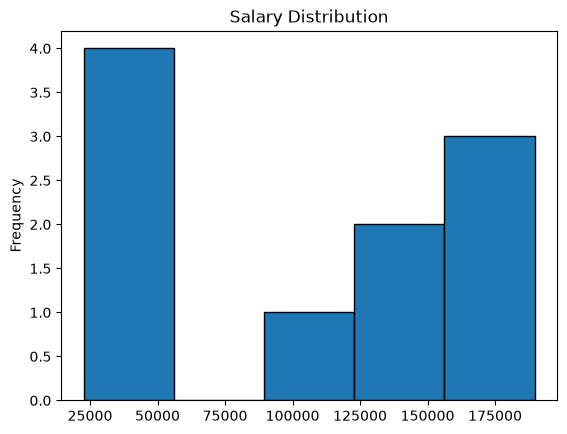

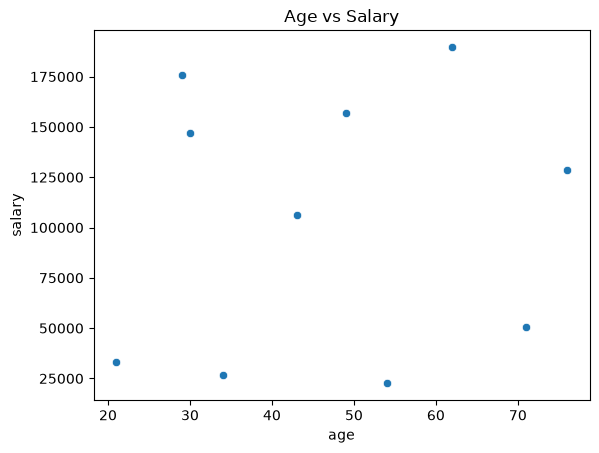

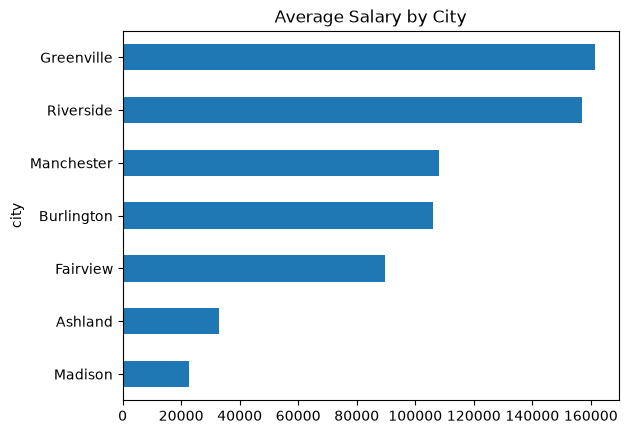

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

df["salary"].plot(kind="hist", bins=5, edgecolor="black", title="Salary Distribution")
plt.show()

sns.scatterplot(data=df, x="age", y="salary")
plt.title("Age vs Salary")
plt.show()

df.groupby("city")["salary"].mean().sort_values().plot(kind="barh", title="Average Salary by City")
plt.show()

Cell 7: Features, target and split

In [7]:
from sklearn.model_selection import train_test_split

X = df[["age", "city", "year"]]
y = df["salary"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(len(X_train), len(X_test))

8 2


## Train a model on Iris (classification)

Load, split and scale

In [8]:
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

iris = load_iris(as_frame=True)
X, y = iris.data, iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

Train your first model (kNN)

In [9]:
from sklearn.neighbors import KNeighborsClassifier

model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train_s, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](3,)","[0,1,2]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


Predict and score

In [10]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test_s)
print("Test accuracy:", round(accuracy_score(y_test, y_pred), 3))
print("Train accuracy:", round(model.score(X_train_s, y_train), 3))

Test accuracy: 0.933
Train accuracy: 0.975
